# Step 4. Exploratory Data Analysis (EDA)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [8]:
clean_data = pd.read_csv('clen_data.csv')


## Phase 4: Exploratory Data Analysis (EDA)

### Step 7: Univariate Analysis

* Analyze individual variables.
* Study distributions.
* Identify trends.
* Detect anomalies.

### Step 8: Bivariate Analysis

* Analyze relationships between two variables.
* Compare categories.
* Measure associations.
* Identify influencing factors.

### Step 9: Multivariate Analysis

* Analyze interactions among multiple variables.
* Discover hidden patterns.
* Evaluate combined effects.
* Explore complex relationships.

### Step 10: Statistical Analysis

* Generate summary statistics.
* Measure variability.
* Analyze distributions.
* Identify correlations.
* Perform statistical validation where applicable.

---

In [9]:
clean_data.head(5)

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cleaned_reviews
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[(4.0, 'A beautiful place to dine in.The inter..."
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[(4.0, 'Had been here for dinner with family. ..."
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[(3.0, ""Ambience is not that good enough and i..."
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[(4.0, ""Great food and proper Karnataka style ..."
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[(4.0, 'Very good restaurant in neighbourhood...."


In [11]:
clean_data

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cleaned_reviews
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[(4.0, 'A beautiful place to dine in.The inter..."
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[(4.0, 'Had been here for dinner with family. ..."
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[(3.0, ""Ambience is not that good enough and i..."
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[(4.0, ""Great food and proper Karnataka style ..."
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[(4.0, 'Very good restaurant in neighbourhood...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,"Four Points by Sheraton Bengaluru, 433, Whitef...",Best Brews Four Points by Sheraton Bengaluru,No,No,3.6,27,Whitefield,Bar,Unknown,Continental,1.0,"[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield,"[(5.0, ""Food and service are incomparably exce..."
51713,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Unknown,Finger Food,600.0,[],[],Pubs and bars,Whitefield,[]
51714,Sheraton Grand Bengaluru Whitefield Hotel Conv...,Plunge Sheraton Grand Bengaluru Whitefield Hotel,No,No,3.7,0,Whitefield,Bar,Unknown,Finger Food,2.0,[],[],Pubs and bars,Whitefield,[]
51715,Sheraton Grand Bengaluru Whitefield Hotel Conv...,Chime Sheraton Grand Bengaluru Whitefield Hotel,No,Yes,4.3,236,ITPL Main Road Whitefield,Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2.0,"[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield,"[(4.0, 'Nice and friendly place and staff is a..."


# ❓ Business Questions

## Objective 1: Market Analysis

### Goal

Understand the restaurant ecosystem in Bengaluru.

### Business Questions

- Which locations have the highest number of restaurants?
- Which restaurant types dominate each location?
- Which cuisines are most popular?
- Which areas have the highest competition?
- Which locations present opportunities for expansion?

---

## Objective 2: Customer Preference Analysis

### Goal

Understand customer behavior and preferences.

### Business Questions

- Which cuisines receive the highest ratings?
- Which restaurants receive the most votes?
- Which restaurant types are most preferred?
- Does online ordering improve customer engagement?
- Does table booking influence restaurant ratings?

---

## Objective 3: Restaurant Performance Analysis

### Goal

Evaluate restaurant success and performance.

### Business Questions

- Which restaurants are the top performers?
- Which locations contain the highest-rated restaurants?
- Which restaurants have high ratings but low visibility?
- Which restaurant categories consistently perform well?

---

## Objective 4: Pricing Strategy Analysis

### Goal

Analyze restaurant pricing and customer value.

### Business Questions

- What is the average cost for two people?
- Which locations have the most expensive restaurants?
- Does higher pricing lead to higher ratings?
- Which cuisines provide the best value for money?

---

## Objective 5: Online Service Analysis

### Goal

Evaluate online ordering and table booking services.

### Business Questions

- What percentage of restaurants provide online ordering?
- Which locations have the highest online ordering adoption?
- Which cuisines benefit the most from online ordering?
- Is there a relationship between online ordering and restaurant ratings?

---

## Objective 6: Business Growth Opportunities

### Goal

Support strategic business expansion.

### Business Questions

- Which locations should Zomato prioritize for expansion?
- Which cuisines have high demand but low competition?
- Which restaurant types should Zomato onboard more aggressively?
- Which areas require promotional campaigns?

Text(0, 0.5, 'Number of Restaurants')

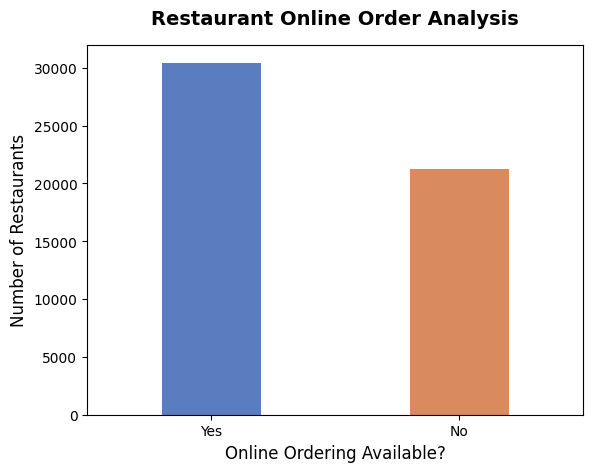

In [12]:
sns.countplot(
    data=clean_data,
    x='online_order',
    stat='count',
    width=0.4,
    hue='online_order',
    palette='muted',
    legend=False
)
plt.title('Restaurant Online Order Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Online Ordering Available?', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

Text(0, 0.5, 'Number of Restaurants')

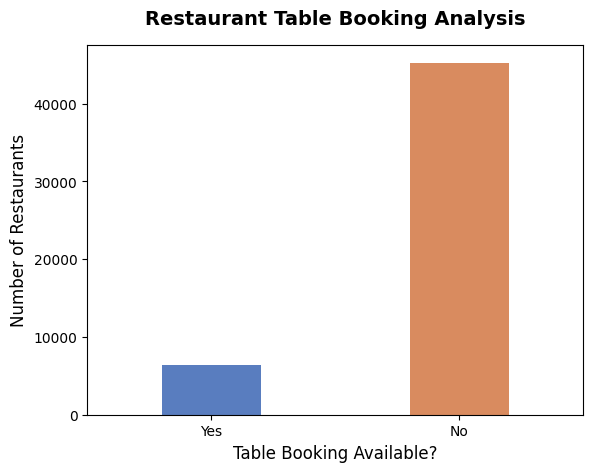

In [13]:
# FIXED: Removed legend=True to prevent Seaborn warnings since hue matches x
sns.countplot(
    data=clean_data,
    x='book_table',
    stat='count',
    width=0.4,              # Slightly narrower bars look cleaner for binary choices
    hue='book_table',
    palette='muted',        # Gives "Yes" and "No" distinct, clean colors
    legend=False            # Disables the redundant legend
)

# FIXED: Corrected spelling to 'Restaurant' and made it descriptive
plt.title('Restaurant Table Booking Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Table Booking Available?', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

# Objective 1: Market Analysis

In [14]:
clean_data['location'].describe()

count     51696
unique       93
top         BTM
freq       5124
Name: location, dtype: object

In [15]:
clean_data['location'].value_counts().head(10).index

Index(['BTM', 'HSR', 'Koramangala 5th Block', 'JP Nagar', 'Whitefield',
       'Indiranagar', 'Jayanagar', 'Marathahalli', 'Bannerghatta Road',
       'Bellandur'],
      dtype='object', name='location')

# Q. Which locations have the highest number of restaurants?

Text(0.5, 1.0, 'Top 10 Most Common Restaurant Location')

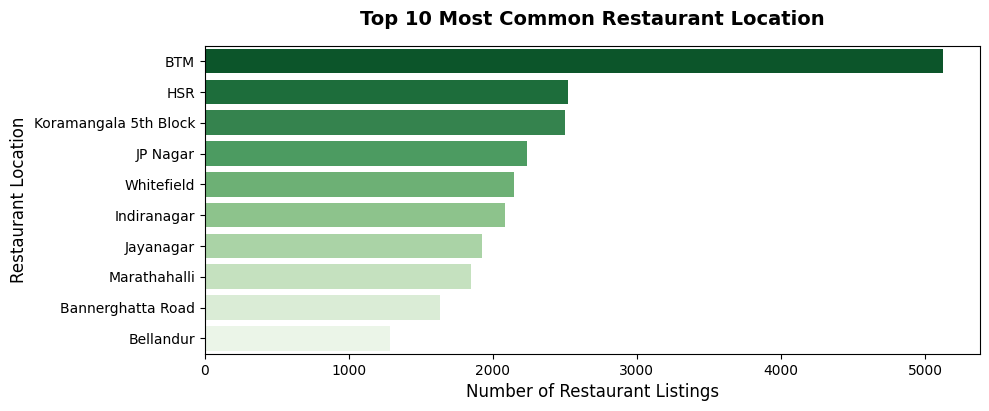

In [16]:
plt.figure(figsize=(10,4))
fliterd_data = clean_data['location'].value_counts().head(10).index
sns.countplot(
    data=clean_data, 
    y='location', 
    order=fliterd_data,
    palette='Greens_r'
)
plt.xlabel('Number of Restaurant Listings', fontsize=12)
plt.ylabel('Restaurant Location', fontsize=12)
plt.title('Top 10 Most Common Restaurant Location', fontsize=14, fontweight='bold', pad=15)

In [17]:
clean_data['rest_type'].describe()

count           51717
unique             93
top       Quick Bites
freq            19359
Name: rest_type, dtype: object

Text(0.5, 1.0, 'Top 10 Most Common Restaurant Types')

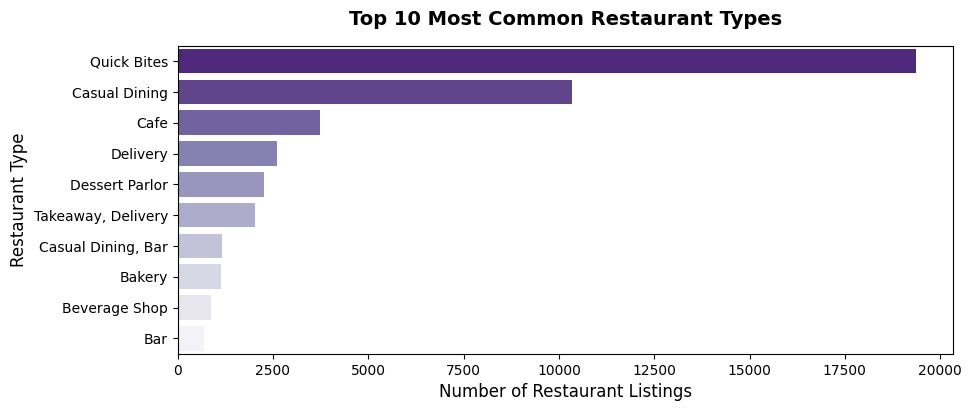

In [18]:
plt.figure(figsize=(10,4))
sns.countplot(
    data=clean_data,
    y='rest_type',
    order=clean_data['rest_type'].value_counts().head(10).index,
    palette='Purples_r'
)
plt.xlabel('Number of Restaurant Listings', fontsize=12)
plt.ylabel('Restaurant Type', fontsize=12)
plt.title('Top 10 Most Common Restaurant Types', fontsize=14, fontweight='bold', pad=15)

# Q. Which restaurant types dominate each location?

In [97]:
# Get the names of the top 10 locations
top_locations = clean_data['location'].value_counts().head(10).index

# Filter your dataset to include only these top 10 locations
filtered_data = clean_data[clean_data['location'].isin(top_locations)]


In [98]:
# Group by location and restaurant type, then count occurrences
grouped_df = filtered_data.groupby(['location', 'rest_type']).size().reset_index(name='count')

# Sort to see the dominant ones at the top
grouped_df = grouped_df.sort_values(by=['location', 'count'], ascending=[True, False])


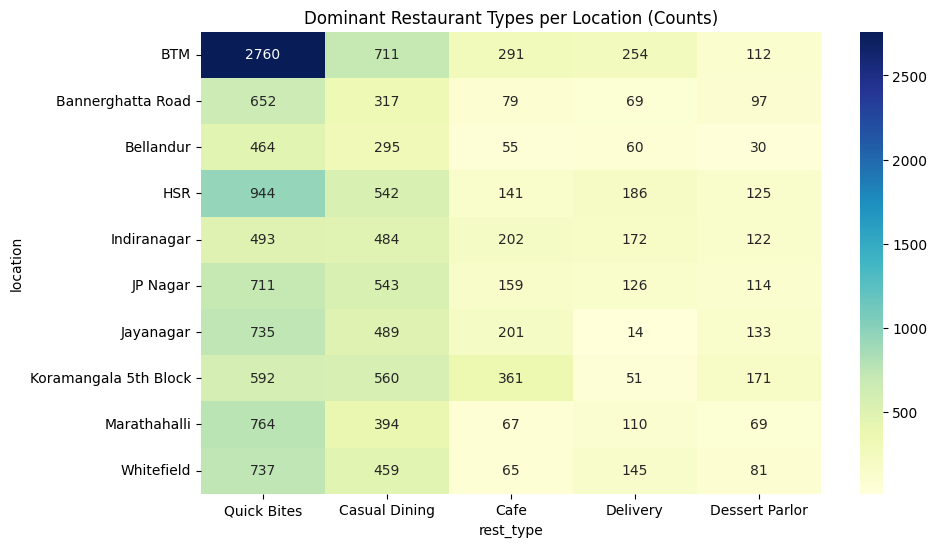

In [101]:
# Create a contingency matrix of counts
crosstab_df = pd.crosstab(filtered_data['location'], filtered_data['rest_type'])

# Keep only the top 5 restaurant types globally to keep the heatmap clean
top_rest_types = clean_data['rest_type'].value_counts().head(5).index
crosstab_df = crosstab_df[top_rest_types]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Dominant Restaurant Types per Location (Counts)')
plt.show()

In [19]:
clean_data['dish_liked'].describe()

count       51717
unique       5272
top       Unknown
freq        28078
Name: dish_liked, dtype: object

In [20]:
# 1. Filter out 'Unknown' rows completely for this analysis
valid_dishes = clean_data[clean_data['dish_liked'] != 'Unknown'].copy()
valid_dishes['dish_liked'].head()

0    Pasta, Lunch Buffet, Masala Papad, Paneer Laja...
1    Momos, Lunch Buffet, Chocolate Nirvana, Thai G...
2    Churros, Cannelloni, Minestrone Soup, Hot Choc...
3                                          Masala Dosa
4                                  Panipuri, Gol Gappe
Name: dish_liked, dtype: object

In [21]:
# 2. Convert to lowercase, split comma-separated dishes, and flatten the list
exploded_dishes = (
    valid_dishes['dish_liked']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
)


In [22]:
# 3. View the clean value counts
print(exploded_dishes.value_counts().head(10))

dish_liked
pasta         3409
burgers       3024
cocktails     2832
pizza         2737
biryani       2092
coffee        1994
mocktails     1887
sandwiches    1676
paratha       1566
noodles       1415
Name: count, dtype: int64


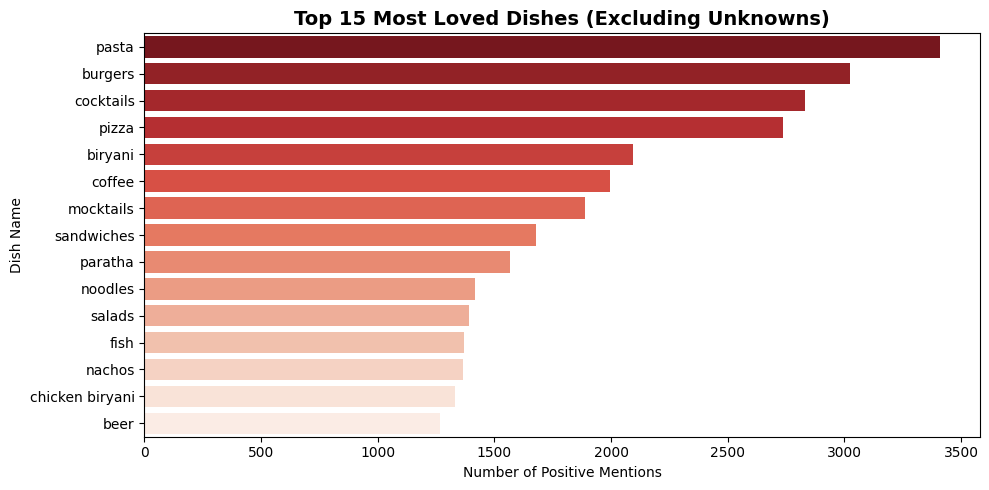

In [23]:
top_15_dishes = exploded_dishes.value_counts().head(15)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_15_dishes.values, 
    y=top_15_dishes.index, 
    palette='Reds_r'
)
plt.title('Top 15 Most Loved Dishes (Excluding Unknowns)', fontsize=14, weight='bold')
plt.xlabel('Number of Positive Mentions')
plt.ylabel('Dish Name')
plt.tight_layout()
plt.show()

In [24]:
clean_data['cuisines'].describe()

count            51717
unique            2723
top       North Indian
freq              2958
Name: cuisines, dtype: object

In [25]:
clean_data['cuisines'].iloc[25:100:20]

25                               Cafe, Bakery
45         North Indian, Continental, Italian
65    North Indian, Kebab, Chinese, Fast Food
85                           Bakery, Desserts
Name: cuisines, dtype: object

In [26]:
# 2. Convert to lowercase, split comma-separated cuisines, and flatten the list
exploded_cuisines = (
    valid_dishes['cuisines']
    .str.lower()
    .str.split(',')
    .explode()
    .str.strip()
)

In [27]:
exploded_cuisines.iloc[:200:25]

0     north indian
10            cafe
20            cafe
35         biryani
47           rolls
55        american
67         mexican
98     street food
Name: cuisines, dtype: object

In [28]:
# 3. View the clean value counts
print(exploded_cuisines.value_counts().head(10))

cuisines
north indian    10234
chinese          7581
continental      4334
cafe             3613
fast food        3273
south indian     2871
italian          2795
desserts         2707
biryani          2634
beverages        2350
Name: count, dtype: int64


# Q.Which cuisines are most popular?

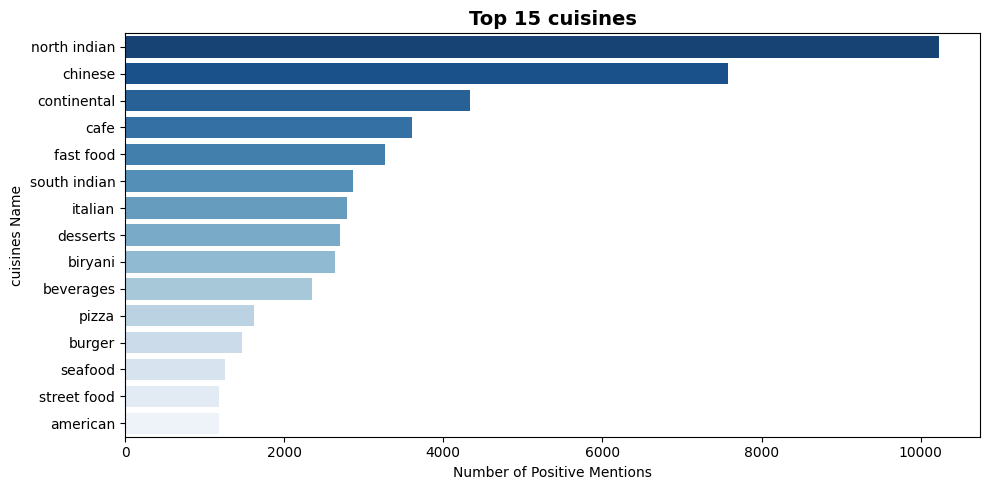

In [29]:
top_15_cuisines = exploded_cuisines.value_counts().head(15)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_15_cuisines.values, 
    y=top_15_cuisines.index, 
    palette='Blues_r'
)
plt.title('Top 15 cuisines', fontsize=14, weight='bold')
plt.xlabel('Number of Positive Mentions')
plt.ylabel('cuisines Name')
plt.tight_layout()
plt.show()

In [30]:
clean_data['menu_item'].describe()

count     51717
unique     9098
top          []
freq      39617
Name: menu_item, dtype: object

In [31]:
clean_data['listed_in(type)'].describe()

count        51717
unique           7
top       Delivery
freq         25942
Name: listed_in(type), dtype: object

Text(0, 0.5, 'Type')

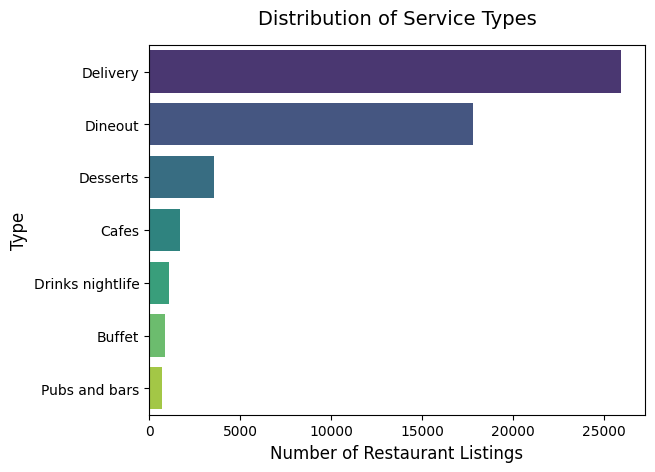

In [32]:
sns.countplot(
    y="listed_in(type)",
    data=clean_data,
    order=clean_data["listed_in(type)"].value_counts().index,  # Sorts from largest to smallest
    palette="viridis",
)
# Add clear labels and title
plt.title("Distribution of Service Types", fontsize=14, pad=15)
plt.xlabel("Number of Restaurant Listings", fontsize=12)
plt.ylabel("Type", fontsize=12)

In [33]:
clean_data['listed_in(city)'].describe()

count     51717
unique       30
top         BTM
freq       3279
Name: listed_in(city), dtype: object

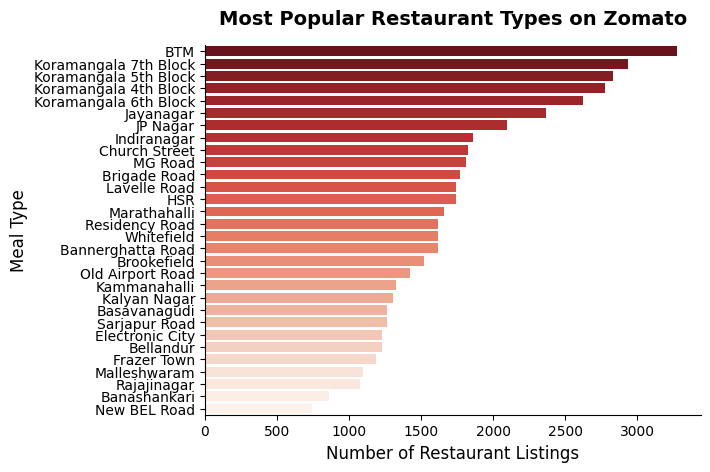

In [102]:
sns.countplot(
    data=clean_data,
    y="listed_in(city)",
    order=clean_data["listed_in(city)"].value_counts().index,
    palette="Reds_r",  # "Reds_r" matches Zomato's brand color scheme!
)

plt.title("Most Popular Restaurant Types on Zomato", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Restaurant Listings", fontsize=12)
plt.ylabel("Meal Type", fontsize=12)
sns.despine() 

In [35]:
clean_data

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cleaned_reviews
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[(4.0, 'A beautiful place to dine in.The inter..."
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[(4.0, 'Had been here for dinner with family. ..."
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[(3.0, ""Ambience is not that good enough and i..."
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[(4.0, ""Great food and proper Karnataka style ..."
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[(4.0, 'Very good restaurant in neighbourhood...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,"Four Points by Sheraton Bengaluru, 433, Whitef...",Best Brews Four Points by Sheraton Bengaluru,No,No,3.6,27,Whitefield,Bar,Unknown,Continental,1.0,"[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield,"[(5.0, ""Food and service are incomparably exce..."
51713,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Unknown,Finger Food,600.0,[],[],Pubs and bars,Whitefield,[]
51714,Sheraton Grand Bengaluru Whitefield Hotel Conv...,Plunge Sheraton Grand Bengaluru Whitefield Hotel,No,No,3.7,0,Whitefield,Bar,Unknown,Finger Food,2.0,[],[],Pubs and bars,Whitefield,[]
51715,Sheraton Grand Bengaluru Whitefield Hotel Conv...,Chime Sheraton Grand Bengaluru Whitefield Hotel,No,Yes,4.3,236,ITPL Main Road Whitefield,Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2.0,"[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield,"[(4.0, 'Nice and friendly place and staff is a..."


In [36]:
clean_data.describe()

,rate,votes,approx_cost(for two people)
count,51717.000000,51717.000000,51717.000000
mean,3.700362,283.697527,360.619584
std,0.395391,803.838853,229.200263
min,1.800000,0.000000,1.000000
25%,3.500000,7.000000,200.000000
50%,3.700000,41.000000,350.000000
75%,3.900000,198.000000,500.000000
max,4.900000,16832.000000,950.000000


In [43]:
clean_data.rate

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    3.7
51714    3.7
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64

In [55]:
clean_data['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

<Axes: xlabel='rate', ylabel='Count'>

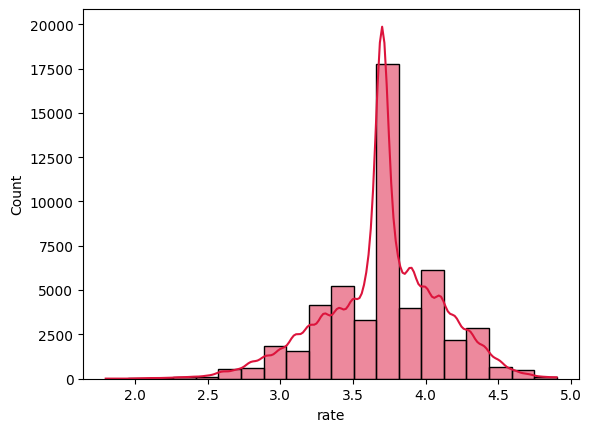

In [57]:
sns.histplot(data=clean_data,x='rate',bins=20,kde=True,color="crimson")

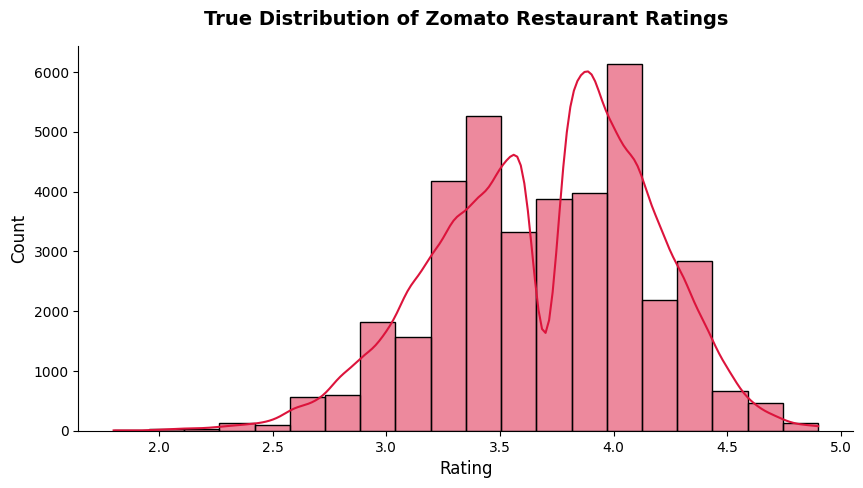

In [59]:
# Create a temporary dataframe that excludes the imputed/filled rating values
# Replace 3.7 with the exact value you used if you imputed your data earlier
true_ratings = clean_data[clean_data['rate'] != 3.7]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=true_ratings,
    x='rate',
    bins=20,          # Dropping bins from 70 to 20 makes the bars smoother
    kde=True,
    color='crimson'
)
plt.title('True Distribution of Zomato Restaurant Ratings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
sns.despine()
plt.show()


In [61]:
clean_data['votes']

0        775
1        787
2        918
3         88
4        166
        ... 
51712     27
51713      0
51714      0
51715    236
51716     13
Name: votes, Length: 51717, dtype: int64

In [72]:
clean_data.votes.describe()

count    51717.000000
mean       283.697527
std        803.838853
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: votes, dtype: float64

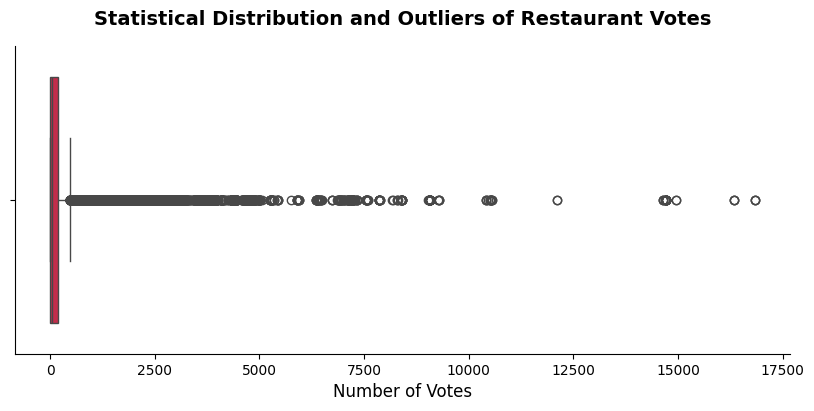

In [75]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=clean_data, x='votes', color='crimson')

plt.title('Statistical Distribution and Outliers of Restaurant Votes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Votes', fontsize=12)
sns.despine()
plt.show()

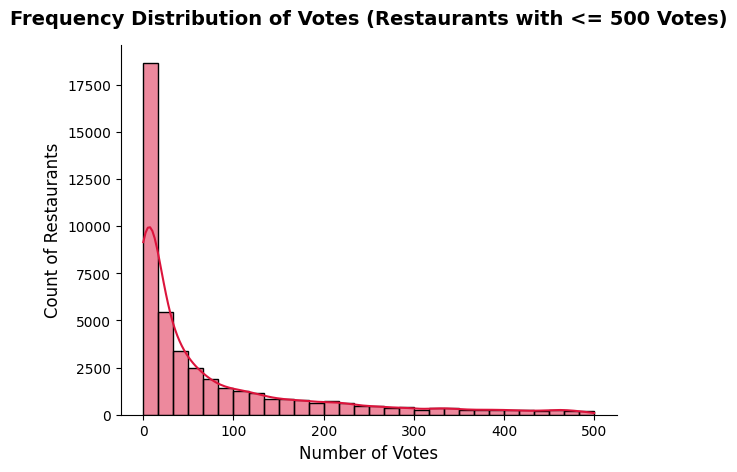

In [76]:
# Filter to look closely at the core distribution (restaurants with <= 500 votes)
core_votes = clean_data[clean_data['votes'] <= 500]

sns.histplot(data=core_votes, x='votes', bins=30, kde=True, color='crimson')

plt.title('Frequency Distribution of Votes (Restaurants with <= 500 Votes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Count of Restaurants', fontsize=12)
sns.despine()
plt.show()

### 📝 Key Finding: Extreme Right-Skew in Votes Distribution
* **Observation:** The `votes` feature exhibits heavy right-skewness ($\text{median} = 41$, $\text{max} = 16,832$). 
* **Statistical Impact:** The top 25% of restaurants hold the vast majority of user engagement, with extreme outliers pulling the mean ($283.7$) far above the median.
* **Action Plan:** Standard linear visualizations will suffer from compression. For downstream modeling or scatter analysis, we must apply a logarithmic transformation (`np.log1p`) or clamp/filter data points above the $Q3 + 1.5 \times \text{IQR}$ threshold ($485$ votes) to preserve visual clarity.


In [88]:
# Find the 95th percentile value (e.g., maybe around 1,200 votes)
clean_data['votes'].quantile(0.25)

7.0

In [89]:
clean_data['votes'].quantile(0.50)

41.0

In [90]:
clean_data['votes'].quantile(0.75)

198.0

In [91]:
Q1 = clean_data['votes'].quantile(0.25)
Q3 = clean_data['votes'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

print("Upper Limit:", upper)

high_vote_restaurants = clean_data[clean_data['votes'] > upper]

high_vote_restaurants[['name', 'location', 'rate', 'votes']].sort_values(
    'votes', ascending=False
).head(20)

Upper Limit: 484.5


,name,location,rate,votes
50059,Byg Brewski Brewing Company,Sarjapur Road,4.9,16832
49627,Byg Brewski Brewing Company,Sarjapur Road,4.9,16832
49170,Byg Brewski Brewing Company,Sarjapur Road,4.9,16832
4944,Byg Brewski Brewing Company,Sarjapur Road,4.9,16345
4801,Byg Brewski Brewing Company,Sarjapur Road,4.9,16345
3921,Byg Brewski Brewing Company,Sarjapur Road,4.9,16345
18643,Toit,Indiranagar,4.7,14956
19268,Toit,Indiranagar,4.7,14956
36668,Truffles,Koramangala 5th Block,4.7,14726
36000,Truffles,Koramangala 5th Block,4.7,14723


In [92]:
clean_data.votes.describe()

count    51717.000000
mean       283.697527
std        803.838853
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: votes, dtype: float64